# Notebook 2 — Classical Eve: breaking RSA without the private key

Eve has intercepted Alice's ciphertext `c` and also knows Bob's public key `(N, e)`. She does **not** know `p`, `q`, or `d`.

Eve's plan is the textbook RSA attack:

1. Factor `N` into `p · q`.
2. Compute `φ(N) = (p-1)(q-1)`.
3. Recover `d = e⁻¹ mod φ(N)`.
4. Decrypt `m = cᵈ mod N`.

Step 1 is the only hard step. At `N = 15` it's instant; at `N ≈ 2^2048` it would not finish in the lifetime of the universe.

This notebook runs **two independent factoring test cases** against the same `N`:

- **Test case A — Trial division** (Section 3). The naive `O(√N)` brute-force baseline.
- **Test case B — Pollard's ρ**  (Section 4). The smarter `O(N^{1/4})` classical algorithm.

Both test cases succeed here because `N = 15` is tiny. The point of running both is to highlight how the choice of algorithm changes the runtime story as `N` grows.

**Canonical demo values (same as Notebook 1):**

| symbol | value |
|--------|-------|
| `N`        | `15` |
| `e`        | `3` |
| `c`        | `2` |
| plaintext (target) | `m = 8` |

In [1]:
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
from sympy import mod_inverse, isprime

%matplotlib inline

## 1. Eve loads the intercepted data

Eve grabs whatever Notebook 1 published. In a real attack she would have sniffed `c` from the network and read `(N, e)` from Bob's certificate. The hardcoded values below mirror Notebook 1 exactly, so this notebook is runnable on its own.

In [ ]:
# Canonical demo values, identical across all three notebooks.
EXPECTED_N = 15
EXPECTED_E = 3
EXPECTED_C = 2
EXPECTED_PLAINTEXT = 8

json_path = Path('rsa_public.json')
if json_path.exists():
    blob = json.loads(json_path.read_text())
    N = blob['N']; e = blob['e']; c = blob['c']
    expected_pt = blob.get('_plaintext_for_verification_only', EXPECTED_PLAINTEXT)
    print(f'loaded public data from {json_path.resolve()}')
else:
    N, e, c = EXPECTED_N, EXPECTED_E, EXPECTED_C
    expected_pt = EXPECTED_PLAINTEXT
    print('rsa_public.json not found - using hardcoded canonical values')

assert (N, e, c) == (EXPECTED_N, EXPECTED_E, EXPECTED_C), \
    'loaded values disagree with the canonical demo values'

print(f'intercepted N = {N}')
print(f'intercepted e = {e}')
print(f'intercepted c = {c}')

## 2. Roadmap of the two factoring test cases

| | Test case A: Trial division | Test case B: Pollard's ρ |
|-|-|-|
| **Idea** | Try every odd divisor up to `√N` | Iterate `x ← x² + c (mod N)`; find a cycle |
| **Asymptotic cost** | `O(√N)` | `O(N^{1/4})` *expected* |
| **Memory** | constant | constant |
| **At `N = 15`** | finds factor in ~1 step | finds factor in ~2 steps |
| **At RSA-2048** | `2^1024` divisions — infeasible | `2^512` iterations — infeasible |

Both algorithms find the same factors. The point of running both is to make the reader feel how the *scaling* differs even when the final answer is identical.

## 3. Test case A — Trial division

Trial division simply tries every candidate divisor up to `√N`. It is the algorithm a programmer would write before they have learned any number theory. At `N = 15` the very first odd candidate `d = 3` already divides `N`, so the test finishes in microseconds. This is the algorithm whose runtime explodes for real RSA moduli.

In [3]:
def trial_division(n):
    '''Smallest non-trivial divisor of n via trial division (test case A).'''
    if n % 2 == 0:
        return 2, n // 2
    limit = math.isqrt(n)
    d = 3
    while d <= limit:
        if n % d == 0:
            return d, n // d
        d += 2
    return None, None

t0 = time.perf_counter()
p_td, q_td = trial_division(N)
td_us = (time.perf_counter() - t0) * 1e6
print(f'[Test case A] trial division found p={p_td}, q={q_td} in {td_us:.1f} us')
assert (p_td, q_td) == (3, 5)

[Test case A] trial division found p=3, q=5 in 607.5 us


## 4. Test case B — Pollard's ρ

Pollard's ρ is a much better classical factoring algorithm. It expects to find a non-trivial factor in `O(N^{1/4})` time using Floyd's cycle detection on the map

$$x_{i+1} = x_i^{2} + c \pmod{N}.$$

Two pointers walk along this sequence — the *tortoise* one step at a time, the *hare* two steps at a time. When `gcd(|x_tortoise − x_hare|, N) > 1`, that gcd is a non-trivial factor of `N` (with high probability). At `N = 15` the rho converges in a couple of iterations; for 2048‑bit RSA it would need `2⁵¹²` iterations, hopelessly out of reach.

In [4]:
def pollard_rho(n, seed=2, cc=1, record=None):
    '''Return a non-trivial factor of n (test case B).
    If `record` is a list, the (x_tortoise, x_hare, gcd) triples are appended for plotting.'''
    if n % 2 == 0:
        return 2
    while True:
        x = seed
        y = seed
        d = 1
        f = lambda v: (v * v + cc) % n
        while d == 1:
            x = f(x)
            y = f(f(y))
            d = math.gcd(abs(x - y), n)
            if record is not None:
                record.append((x, y, d))
        if d != n:
            return d
        seed += 1
        cc   += 1
        if record is not None:
            record.append(('reset', seed, cc))

rho_trace = []
t0 = time.perf_counter()
p_eve = int(pollard_rho(N, record=rho_trace))
q_eve = N // p_eve
rho_us = (time.perf_counter() - t0) * 1e6

if p_eve > q_eve:
    p_eve, q_eve = q_eve, p_eve

assert p_eve * q_eve == N
assert isprime(p_eve) and isprime(q_eve)
print(f'[Test case B] Pollard rho cracked N in {rho_us:.1f} us')
print(f'  p = {p_eve}')
print(f'  q = {q_eve}')
print(f'  iteration trace ({len(rho_trace)} steps):')
for step in rho_trace:
    print(f'    {step}')
assert (p_eve, q_eve) == (3, 5)

[Test case B] Pollard rho cracked N in 172.0 us
  p = 3
  q = 5
  iteration trace (1 steps):
    (5, 11, 3)


## 5. Side-by-side comparison of the two test cases

The bar chart below shows both wall-clock times. They are both microseconds at this size — but the asymptotic separation is what matters for real RSA.

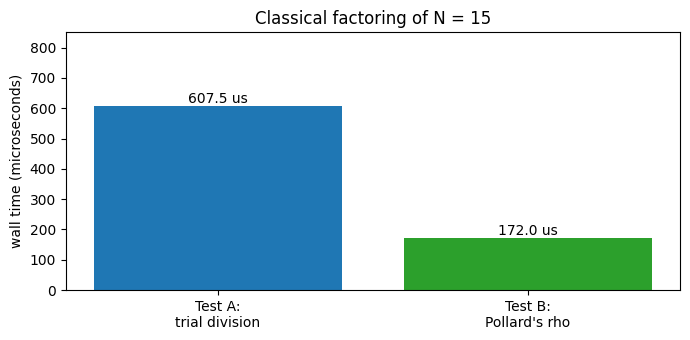

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
labels  = ['Test A:\ntrial division', "Test B:\nPollard's rho"]
times   = [td_us, rho_us]
colors  = ['C0', 'C2']
bars    = ax.bar(labels, times, color=colors)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.1f} us',
            ha='center', va='bottom')
ax.set_ylabel('wall time (microseconds)')
ax.set_title(f'Classical factoring of N = {N}')
ax.set_ylim(0, max(times) * 1.4)
fig.tight_layout(); plt.show()

## 6. Recover the private key and decrypt the ciphertext

Once `p` and `q` are known (from either test case — the results are identical), Eve can reconstruct everything Bob kept private: `φ(N)`, then `d`, then `m`.

In [6]:
phi_eve = (p_eve - 1) * (q_eve - 1)
d_eve   = int(mod_inverse(e, phi_eve))
m_eve   = pow(c, d_eve, N)

print(f'phi(N)       = {phi_eve}')
print(f'recovered d  = {d_eve}')
print(f'decrypted m  = c^d mod N = {c}^{d_eve} mod {N} = {m_eve}')

# Pin against the canonical values from Notebook 1.
assert phi_eve == 8
assert d_eve   == 3
assert m_eve   == expected_pt == 8
print("\nEve has recovered Alice's secret integer - RSA is broken when N is factorable.")

phi(N)       = 8
recovered d  = 3
decrypted m  = c^d mod N = 2^3 mod 15 = 8

Eve has recovered Alice's secret integer - RSA is broken when N is factorable.


## 7. Why this does not scale

The best known classical factoring algorithm is the **General Number Field Sieve (GNFS)**, far better than either test case above. Its complexity is sub-exponential

$$L_N\!\left[\tfrac{1}{3},\,\sqrt[3]{\tfrac{64}{9}}\right] = \exp\!\left(\left(\sqrt[3]{\tfrac{64}{9}}+o(1)\right)(\ln N)^{1/3}(\ln\ln N)^{2/3}\right).$$

Order-of-magnitude estimates (CPU-years on a single fast core):

| RSA modulus size | Status                          |
|------------------|---------------------------------|
| 512 bits         | broken (a long weekend)         |
| 768 bits         | broken (RSA-768, 2009, ~2000 CPU‑years) |
| 1024 bits        | considered breakable by nation states |
| 2048 bits        | far out of reach classically    |
| 4096 bits        | not even close                  |

Both test cases above were instant only because `N = 15`. Real RSA stays alive on the assumption that *no faster classical algorithm exists*. **Notebook 3 shows that this assumption fails on a quantum computer.**